# Model training and evaluation

Neither of the original notebooks ever produced a real evaluation
number. `Sentiment140.ipynb`'s model ends in
`Dense(1, activation='softmax')`, softmax on a single unit always
outputs exactly 1.0 regardless of input, a probability that's
meaningless by construction, and `dummy_train.reshape(8000000, 1)`
flattens what should have been a (1,600,000, 5) one-hot matrix into a
single column of 8 million numbers, destroying the class structure
before it ever reaches the model. Its sibling notebook
(`twitter_sentiment.ipynb`) fares no better: it scales raw integer
token IDs with `StandardScaler` (token IDs are categories, not
continuous quantities, scaling them is meaningless) and relies on the
long-removed `tf.contrib.tpu` API. Both also skip a genuine train/test
split entirely, `test.csv` is loaded once and never touched again.

This rebuild trains logistic regression and random forest on the
TF-IDF features from notebook 02, with a real stratified train/test
split on the 20,000-tweet sample, then, more importantly, an actual
external evaluation on Stanford's own 359 binary-scorable hand-labeled
tweets, a genuinely different data source than what any of these
models were trained on.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/model_matrix.pkl', 'rb') as f:
    d = pickle.load(f)
X_train_full, y_train_full = d['X_train'], d['y_train']
X_official_test, y_official_test = d['X_test'], d['y_test']
X_train_full.shape, X_official_test.shape

((20000, 5000), (359, 5000))

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size = 0.2, stratify = y_train_full, random_state = 42
)
X_train.shape, X_val.shape

((16000, 5000), (4000, 5000))

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

baseline_acc = max(y_val.mean(), 1 - y_val.mean())

logreg = LogisticRegression(max_iter = 1000, random_state = 42)
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators = 300, max_depth = 20, random_state = 42, n_jobs = -1)
rf.fit(X_train, y_train)

results = {'baseline (majority class)': {'val_acc': float(baseline_acc)}}
for name, model in [('logistic_regression', logreg), ('random_forest', rf)]:
    val_pred = model.predict(X_val)
    results[name] = {
        'val_acc': float(accuracy_score(y_val, val_pred)),
        'val_f1': float(f1_score(y_val, val_pred)),
        'val_auc': float(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])),
    }
pd.DataFrame(results).T

,val_acc,val_f1,val_auc
baseline (majority class),0.50000,NaN,NaN
logistic_regression,0.76600,0.767048,0.844600
random_forest,0.72125,0.730871,0.794571


### The real test: Stanford's own hand-labeled tweets, never touched during training

In [4]:
official_results = {}
for name, model in [('logistic_regression', logreg), ('random_forest', rf)]:
    pred = model.predict(X_official_test)
    official_results[name] = {
        'official_test_acc': float(accuracy_score(y_official_test, pred)),
        'official_test_f1': float(f1_score(y_official_test, pred)),
        'official_test_auc': float(roc_auc_score(y_official_test, model.predict_proba(X_official_test)[:, 1])),
    }
official_baseline = max(y_official_test.mean(), 1 - y_official_test.mean())
official_results['baseline (majority class)'] = {'official_test_acc': float(official_baseline)}
pd.DataFrame(official_results).T

,official_test_acc,official_test_f1,official_test_auc
logistic_regression,0.788301,0.801047,0.871391
random_forest,0.715877,0.745000,0.787453
baseline (majority class),0.506964,NaN,NaN


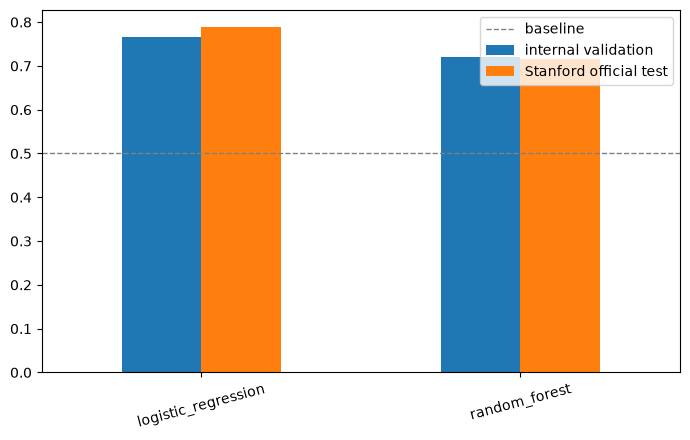

In [5]:
best_name = max(['logistic_regression', 'random_forest'], key = lambda k: official_results[k]['official_test_acc'])
best_model = {'logistic_regression': logreg, 'random_forest': rf}[best_name]

fig, ax = plt.subplots(figsize = (7, 4.5))
comparison = pd.DataFrame({
    'internal validation': {k: results[k]['val_acc'] for k in results if k != 'baseline (majority class)'},
    'Stanford official test': {k: official_results[k]['official_test_acc'] for k in official_results if k != 'baseline (majority class)'},
})
comparison.plot.bar(ax = ax)
ax.axhline(baseline_acc, color = 'gray', linestyle = '--', linewidth = 1, label = 'baseline')
ax.legend()
plt.xticks(rotation = 15)
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi = 120)
plt.show()

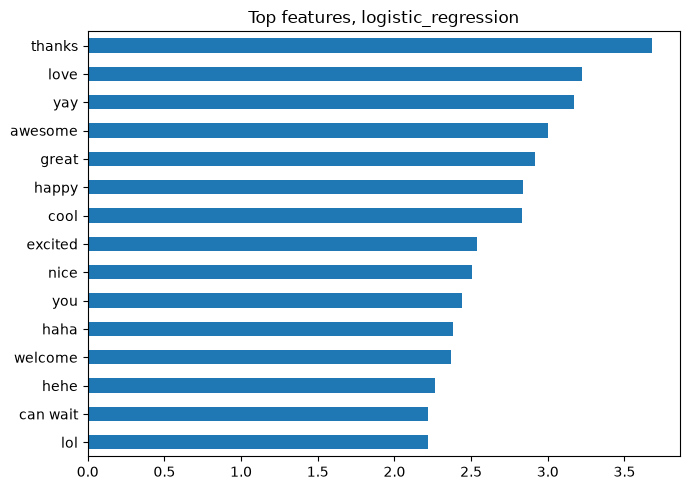

thanks      3.678253
love        3.224535
yay         3.173835
awesome     3.002126
great       2.919554
happy       2.836875
cool        2.830788
excited     2.537585
nice        2.505630
you         2.438419
haha        2.380495
welcome     2.366147
hehe        2.263693
can wait    2.218318
lol         2.215808
dtype: float64

In [6]:
if hasattr(best_model, 'feature_importances_'):
    with open('data/vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    importances = pd.Series(best_model.feature_importances_, index = vectorizer.get_feature_names_out())
    importances = importances.sort_values(ascending = False).head(15)
else:
    with open('data/vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    importances = pd.Series(best_model.coef_[0], index = vectorizer.get_feature_names_out())
    importances = importances.sort_values(ascending = False).head(15)

fig, ax = plt.subplots(figsize = (7, 5))
importances.sort_values().plot.barh(ax = ax)
ax.set_title(f'Top features, {best_name}')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi = 120)
plt.show()
importances

In [7]:
import json, os
os.makedirs('outputs', exist_ok = True)
with open('outputs/model_results.json', 'w') as f:
    json.dump({
        'internal_validation': results,
        'official_test': official_results,
        'best_model': best_name,
    }, f, indent = 2)